# 09 — Uncertainty, significance, residual diagnostics and the revised Figures 2, 3 and 5

**Purpose.** Attach moving-block bootstrap intervals to every reported error, test model differences
with the Diebold–Mariano test, examine residual autocorrelation, seasonal bias, heteroscedasticity and
calibration, and rebuild Figures 2, 3 and 5.

**Answers:** Reviewer 3 comment 5; Reviewer 4 comments 6, 7 and 13.

**Inputs:** `original_protocol_predictions.csv` (07), `rolling_origin_predictions.csv` (08).
**Outputs:** `tables/S9_holdout_uncertainty.csv`, `tables/S10_rolling_origin_uncertainty.csv`,
`tables/S11_seasonal_monthly_errors.csv`, figures `fig2_rolling_origin`, `fig3_series_scatter`,
`fig5_month_year_skill`, `figS4_residual_diagnostics`. **Runtime:** ~5 min.

In [1]:
# --- Setup: Drive, paths, shared helpers -------------------------------------------------------
import os, sys, json, time, warnings, subprocess
warnings.filterwarnings('ignore')
try:
    from google.colab import drive
    drive.mount('/content/drive')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'optuna', 'shap', 'scienceplots',
                    'ephem', 'catboost', 'lightgbm'], check=False)
except Exception:
    pass
_BASE = os.environ.get('SARKOY_BASE', '/content/drive/MyDrive/windforecast_rev1/')
sys.path.insert(0, os.path.join(_BASE, 'revision'))
if not os.path.exists(os.path.join(_BASE, 'revision', 'revision_utils.py')):
    raise FileNotFoundError('Copy revision_utils.py into ' + os.path.join(_BASE, 'revision') + ' first.')
import revision_utils as ru
import numpy as np, pandas as pd, matplotlib.pyplot as plt
BASE, REV, IN_COLAB, FAST = ru.get_paths()
ru.set_style()
RES = ru.Results(REV)
RES.path = REV + 'results_09.json'
GPU = ru.has_gpu()
try:
    from IPython.display import display
except Exception:
    display = print
print('BASE:', BASE, '| REV:', REV, '| GPU:', GPU, '| FAST (smoke test):', FAST)
print(ru.log_versions(REV))


Mounted at /content/drive
BASE: /content/drive/MyDrive/windforecast_rev1/ | REV: /content/drive/MyDrive/windforecast_rev1/revision/ | GPU: False | FAST (smoke test): False
{'python': '3.13.15', 'numpy': '2.1.3', 'pandas': '2.2.3', 'sklearn': '1.6.1', 'scipy': '1.16.3', 'xgboost': '3.4.1', 'lightgbm': '4.6.0', 'catboost': '1.2.10', 'optuna': '5.0.0', 'shap': '0.52.0', 'statsmodels': '0.15.0', 'matplotlib': '3.10.0', 'seaborn': '0.13.2', 'pyarrow': '23.0.1', 'ephem': '4.2.1', 'tensorflow': '2.20.0', 'gpu': False}


In [2]:
# --- Configuration ------------------------------------------------------------------------------
BLOCK, B = 7, (200 if FAST else 2000)
BLOCK_SENS = [14, 30]
TREES = ['Random Forest', 'LightGBM', 'CatBoost', 'XGBoost (400 trials)']
RO_TREES = ['RandomForest', 'LightGBM', 'CatBoost', 'XGBoost_selected']
P = pd.read_csv(REV + 'original_protocol_predictions.csv', parse_dates=['date']).set_index('date')
te = P[(P.split == 'test') & P.target_observed.astype(bool)]
models = [c for c in P.columns if c not in ('y_true', 'split', 'target_observed') and te[c].notna().all()]
print(len(te), 'test days |', len(models), 'models')


364 test days | 15 models


In [3]:
# --- Hold-out year: intervals and paired tests ---------------------------------------------------
bs = ru.block_bootstrap(te.y_true, {m: te[m] for m in models}, block=BLOCK, B=B)
ref = 'Persistence'
rows = []
for m in models:
    pt = ru.metrics(te.y_true, te[m])
    lo, hi = ru.ci(bs[m]['RMSE']); mlo, mhi = ru.ci(bs[m]['MAE'])
    sk = 100 * (1 - bs[m]['RMSE'] / bs[ref]['RMSE']); slo, shi = ru.ci(sk)
    if m == ref:
        stat, p = np.nan, np.nan
    else:
        stat, p, _ = ru.dm_test(te.y_true - te[m], te.y_true - te[ref])
    rows.append(dict(model=m, **pt, RMSE_lo=lo, RMSE_hi=hi, MAE_lo=mlo, MAE_hi=mhi,
                     skill_pct=100 * (1 - pt['RMSE'] / ru.rmse(te.y_true, te[ref])),
                     skill_lo=slo, skill_hi=shi, DM_vs_persistence=stat, p_vs_persistence=p))
H = pd.DataFrame(rows)
H.to_csv(REV + 'tables/S9_holdout_uncertainty.csv', index=False)
display(H.round(4))
for _, r in H.iterrows():
    code = ru.MODEL_CODES.get(r.model)
    if code:
        RES.put(f'T1_{code}_RMSE_CI', ru.fmt_ci(r.RMSE_lo, r.RMSE_hi))
        RES.put(f'T1_{code}_MAE_CI', ru.fmt_ci(r.MAE_lo, r.MAE_hi))
Hi = H.set_index('model')
learned = [m for m in H.model if m not in (ref, 'Seasonal-naive', '7-day moving average')]
sig = [m for m in learned if Hi.loc[m, 'p_vs_persistence'] < 0.05 and Hi.loc[m, 'skill_pct'] > 0]
tree_like = [m for m in learned if m in TREES or m.startswith('XGBoost')]
RES.put('T1_SIG_SENTENCE', 'only the tree ensembles improved on persistence significantly; the linear models, '
        'SVR and the LSTM did not' if set(sig) == set(tree_like) else
        f'{len(sig)} of the {len(learned)} learned models improved on persistence significantly')
xg = H[H.model == 'XGBoost (400 trials)'].iloc[0]
RES.put('T1_XGB400_SKILL', xg.skill_pct, '.1f').put('T1_XGB400_SKILL_CI', ru.fmt_ci(xg.skill_lo, xg.skill_hi, 1))
RES.put('T1_XGB400_DM_P', ('< 0.001' if xg.p_vs_persistence < 0.001 else f'= {xg.p_vs_persistence:.3f}'))
for L in BLOCK_SENS:
    b2 = ru.block_bootstrap(te.y_true, {m: te[m] for m in ('XGBoost (400 trials)', ref)}, block=L, B=B)
    lo, hi = ru.ci(100 * (1 - b2['XGBoost (400 trials)']['RMSE'] / b2[ref]['RMSE']))
    RES.put(f'T1_XGB400_SKILL_CI_L{L}', ru.fmt_ci(lo, hi, 1))


,model,RMSE,MAE,R2,MaxAE,n,RMSE_lo,RMSE_hi,MAE_lo,MAE_hi,skill_pct,skill_lo,skill_hi,DM_vs_persistence,p_vs_persistence
0,Persistence,1.1294,0.8338,0.2527,4.4000,364,0.9918,1.2532,0.7439,0.9203,0.0000,0.0000,0.0000,NaN,NaN
1,Seasonal-naive,1.4605,1.1312,-0.2498,5.3571,364,1.2457,1.5992,0.9866,1.2412,-29.3233,-42.2927,-12.6160,3.4499,0.0006
2,7-day moving average,1.2906,0.9507,0.0242,5.7714,364,1.0656,1.4740,0.8081,1.0763,-14.2737,-24.8797,-1.2666,2.0477,0.0413
3,LassoCV,1.1077,0.8590,0.2812,4.8855,364,0.9699,1.2151,0.7692,0.9352,1.9205,-5.4565,9.9320,-0.4589,0.6466
4,RidgeCV,1.1472,0.8882,0.2289,4.9584,364,1.0246,1.2597,0.7992,0.9739,-1.5823,-11.3866,5.9164,0.3695,0.7120
5,ElasticNetCV,1.0760,0.8366,0.3216,4.6194,364,0.9500,1.1775,0.7519,0.9102,4.7229,-2.6774,11.9369,-1.1983,0.2316
6,SVR,1.0675,0.8220,0.3324,4.9127,364,0.9293,1.1815,0.7334,0.9014,5.4794,-2.2307,12.7954,-1.3723,0.1708
7,Random Forest,0.9741,0.7488,0.4441,4.5551,364,0.8673,1.0825,0.6774,0.8174,13.7519,7.9172,18.7516,-3.9943,0.0001
8,LightGBM,0.9659,0.7444,0.4534,4.4609,364,0.8603,1.0768,0.6754,0.8121,14.4732,8.2925,19.3372,-4.0382,0.0001
9,CatBoost,0.9706,0.7474,0.4481,4.5811,364,0.8597,1.0738,0.6773,0.8127,14.0612,8.4174,19.3937,-4.0039,0.0001


In [4]:
# --- Are the tree ensembles distinguishable? -----------------------------------------------------
pairs, ps = [], []
avail = [m for m in TREES if m in models]
for i in range(len(avail)):
    for j in range(i + 1, len(avail)):
        s, p, _ = ru.dm_test(te.y_true - te[avail[i]], te.y_true - te[avail[j]])
        pairs.append((avail[i], avail[j], s, p))
padj = ru.holm([p for *_, p in pairs]) if pairs else []
PW = pd.DataFrame([dict(model_a=a, model_b=b, DM=s, p=p, p_holm=q) for (a, b, s, p), q in zip(pairs, padj)])
PW.to_csv(REV + 'tables/S9_tree_pairwise_dm.csv', index=False)
display(PW.round(4))
nsig = int((PW.p_holm < 0.05).sum()) if len(PW) else 0
RES.put('T1_TREE_NPAIR', len(PW), 'd').put('T1_TREE_NSIG', nsig, 'd')
RES.put('T1_TREE_SIG_SENTENCE',
        'none of the six pairwise differences was significant at the 5% level (Holm-adjusted)' if nsig == 0
        else f'{nsig} of the {len(PW)} pairwise differences were significant at the 5% level (Holm-adjusted)')
err = (te.y_true - te['XGBoost (400 trials)']).abs()
d = err.idxmax()
RES.put('T1_MAXERR', err.max(), '.2f').put('T1_MAXERR_DATE', (d + pd.Timedelta(days=1)).strftime('%d %B %Y').lstrip('0'))
RES.put('T1_MAXERR_OBS', te.loc[d, 'y_true'], '.1f').put('T1_MAXERR_PREV', te.loc[d, 'Persistence'], '.1f')


,model_a,model_b,DM,p,p_holm
0,Random Forest,LightGBM,0.8871,0.3756,1.0000
1,Random Forest,CatBoost,0.2975,0.7662,1.0000
2,Random Forest,XGBoost (400 trials),1.9763,0.0489,0.2933
3,LightGBM,CatBoost,-0.3419,0.7327,1.0000
4,LightGBM,XGBoost (400 trials),1.2686,0.2054,1.0000
5,CatBoost,XGBoost (400 trials),1.1763,0.2403,1.0000


In [5]:
# --- Rolling-origin: per-year and pooled intervals ------------------------------------------------
R = pd.read_csv(REV + 'rolling_origin_predictions.csv', parse_dates=['date'])
mods = [c for c in R.columns if c not in ('date', 'outer_year', 'y_true') and R[c].notna().all()]
rows = []
for Y, g in R.groupby('outer_year'):
    bb = ru.block_bootstrap(g.y_true, {m: g[m] for m in mods}, block=BLOCK, B=B)
    for m in mods:
        lo, hi = ru.ci(bb[m]['RMSE'])
        sk = 100 * (1 - bb[m]['RMSE'] / bb['persistence']['RMSE']); slo, shi = ru.ci(sk)
        st, p, _ = ru.dm_test(g.y_true - g[m], g.y_true - g.persistence) if m != 'persistence' else (np.nan,) * 3
        rows.append(dict(outer_year=Y, model=m, **ru.metrics(g.y_true, g[m]), RMSE_lo=lo, RMSE_hi=hi,
                         skill_pct=100 * (1 - ru.rmse(g.y_true, g[m]) / ru.rmse(g.y_true, g.persistence)),
                         skill_lo=slo, skill_hi=shi, DM=st, p=p))
bb = ru.block_bootstrap(R.y_true, {m: R[m] for m in mods}, block=BLOCK, B=B, groups=R.outer_year.to_numpy())
for m in mods:
    lo, hi = ru.ci(bb[m]['RMSE'])
    sk = 100 * (1 - bb[m]['RMSE'] / bb['persistence']['RMSE']); slo, shi = ru.ci(sk)
    st, p, _ = ru.dm_test(R.y_true - R[m], R.y_true - R.persistence) if m != 'persistence' else (np.nan,) * 3
    rows.append(dict(outer_year='pooled', model=m, **ru.metrics(R.y_true, R[m]), RMSE_lo=lo, RMSE_hi=hi,
                     skill_pct=100 * (1 - ru.rmse(R.y_true, R[m]) / ru.rmse(R.y_true, R.persistence)),
                     skill_lo=slo, skill_hi=shi, DM=st, p=p))
U = pd.DataFrame(rows)
U.to_csv(REV + 'tables/S10_rolling_origin_uncertainty.csv', index=False)
display(U[U.model.isin(['persistence', 'XGBoost_selected'])].round(3))
xs = U[(U.model == 'XGBoost_selected')]
per_year = xs[xs.outer_year != 'pooled']
pool = xs[xs.outer_year == 'pooled'].iloc[0]
RES.put('RO_SKILL_MIN', per_year.skill_pct.min(), '.1f').put('RO_SKILL_MAX', per_year.skill_pct.max(), '.1f')
RES.put('RO_POOLED_SKILL', pool.skill_pct, '.1f').put('RO_POOLED_SKILL_CI', ru.fmt_ci(pool.skill_lo, pool.skill_hi, 1))
RES.put('RO_POOLED_XGB_RMSE', pool.RMSE, '.3f').put('RO_POOLED_XGB_RMSE_CI', ru.fmt_ci(pool.RMSE_lo, pool.RMSE_hi))
RES.put('RO_XGB_RMSE_MIN', per_year.RMSE.min(), '.3f').put('RO_XGB_RMSE_MAX', per_year.RMSE.max(), '.3f')
RES.put('RO_NSIG', int((per_year.p < 0.05).sum()), 'd')
pooled_trees = U[(U.outer_year == 'pooled') & (U.model.isin(RO_TREES))]
RES.put('RO_TREE_SPREAD', pooled_trees.RMSE.max() - pooled_trees.RMSE.min(), '.3f')
pairs, ps = [], []
for i in range(len(RO_TREES)):
    for j in range(i + 1, len(RO_TREES)):
        if RO_TREES[i] in mods and RO_TREES[j] in mods:
            s, p, _ = ru.dm_test(R.y_true - R[RO_TREES[i]], R.y_true - R[RO_TREES[j]])
            pairs.append((RO_TREES[i], RO_TREES[j], s, p))
padj = ru.holm([p for *_, p in pairs]) if pairs else []
nsig = int((np.asarray(padj) < 0.05).sum()) if len(padj) else 0
RES.put('RO_TREE_SIG_SENTENCE', ('no pairwise difference between them was significant'
                                 if nsig == 0 else f'{nsig} of {len(padj)} pairwise differences were significant'))
if 'XGBoost_origin_t-1' in mods:
    sk_t1 = 100 * (1 - ru.rmse(R.y_true, R['XGBoost_origin_t-1']) / ru.rmse(R.y_true, R['persistence_2d']))
    RES.put('RO_T1_SKILL', sk_t1, '.1f').put('RO_T1_RMSE', ru.rmse(R.y_true, R['XGBoost_origin_t-1']), '.3f')
    RES.put('RO_T1_PERS_RMSE', ru.rmse(R.y_true, R['persistence_2d']), '.3f')


,outer_year,model,RMSE,MAE,R2,MaxAE,n,RMSE_lo,RMSE_hi,skill_pct,skill_lo,skill_hi,DM,p
0,2020,persistence,1.409,1.025,0.189,7.300,366,1.227,1.566,0.000,0.000,0.000,NaN,NaN
11,2020,XGBoost_selected,1.069,0.819,0.533,4.499,366,0.941,1.177,24.144,18.806,28.908,-5.300,0.0
13,2021,persistence,1.327,0.974,0.054,5.100,363,1.146,1.519,0.000,0.000,0.000,NaN,NaN
24,2021,XGBoost_selected,1.020,0.767,0.441,3.436,363,0.898,1.130,23.180,16.151,29.916,-4.142,0.0
26,2022,persistence,1.383,1.028,0.016,4.900,365,1.229,1.541,0.000,0.000,0.000,NaN,NaN
37,2022,XGBoost_selected,0.986,0.764,0.500,3.546,365,0.891,1.079,28.693,24.766,32.405,-6.394,0.0
39,2023,persistence,1.360,0.977,0.071,6.400,364,1.171,1.569,0.000,0.000,0.000,NaN,NaN
50,2023,XGBoost_selected,1.027,0.777,0.470,5.605,364,0.889,1.183,24.477,18.548,30.356,-4.775,0.0
52,2024,persistence,1.129,0.834,0.253,4.400,364,0.992,1.253,0.000,0.000,0.000,NaN,NaN
63,2024,XGBoost_selected,0.953,0.736,0.468,4.505,364,0.851,1.062,15.609,9.666,20.639,-4.331,0.0


In [6]:
# --- Residual diagnostics of the rolling-origin forecasts ----------------------------------------
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
e = (R.y_true - R.XGBoost_selected).to_numpy()
acf1 = float(pd.Series(e).autocorr(1))
lb = acorr_ljungbox(e, lags=[7, 14], return_df=True)
bp_p = float(het_breuschpagan(e, sm.add_constant(R.XGBoost_selected.to_numpy()))[1])
mz = sm.OLS(R.y_true.to_numpy(), sm.add_constant(R.XGBoost_selected.to_numpy())).fit(
    cov_type='HAC', cov_kwds={'maxlags': 7})
slope, inter = float(mz.params[1]), float(mz.params[0])
s_lo, s_hi = [float(v) for v in mz.conf_int()[1]]
month = R.date.dt.month
mb = R.assign(e=e, month=month).groupby('month').e.agg(['mean', 'std', 'size'])
mb['se'] = mb['std'] / np.sqrt(mb['size'])
season = R.assign(e=e, season=pd.cut(month % 12 // 3, [-1, 0, 1, 2, 3],
                                     labels=['DJF', 'MAM', 'JJA', 'SON']))
srows = []
for s, g in season.groupby('season', observed=True):
    srows.append(dict(season=s, days=len(g), RMSE_xgb=ru.rmse(g.y_true, g.XGBoost_selected),
                      RMSE_persistence=ru.rmse(g.y_true, g.persistence), bias=float(g.e.mean()),
                      skill_pct=100 * (1 - ru.rmse(g.y_true, g.XGBoost_selected) / ru.rmse(g.y_true, g.persistence))))
S = pd.DataFrame(srows)
pd.concat([mb.reset_index().assign(kind='month'), S.assign(kind='season')], axis=0).to_csv(
    REV + 'tables/S11_seasonal_monthly_errors.csv', index=False)
display(S.round(3))
het = 'error spread that grows with the forecast level' if bp_p < 0.05 else 'no clear dependence of the error spread on the forecast level'
RES.put('DIAG_ACF1', acf1, '.2f').put('DIAG_LB7_P', ru.fmt_p(float(lb.lb_pvalue.iloc[0])))
RES.put('DIAG_BP_P', ru.fmt_p(bp_p)).put('MZ_SLOPE', slope, '.2f').put('MZ_INTERCEPT', inter, '.2f')
RES.put('MZ_SLOPE_CI', ru.fmt_ci(s_lo, s_hi, 2))
RES.put('DIAG_SENTENCE', f'a lag-1 residual autocorrelation of {acf1:.2f} (Ljung–Box p {ru.fmt_p(float(lb.lb_pvalue.iloc[0]))} '
        f'at seven lags), a monthly mean error between {mb["mean"].min():.2f} and {mb["mean"].max():.2f} m/s, and {het}')
RES.put('MZ_SENTENCE', f'a slope of {slope:.2f} (95% interval {ru.fmt_ci(s_lo, s_hi, 2)}), ' +
        ('consistent with calibrated forecasts' if s_lo <= 1 <= s_hi else
         ('which indicates forecasts that are too smooth' if s_lo > 1 else 'which indicates over-dispersed forecasts')))
RES.put('SEASON_BEST', S.loc[S.skill_pct.idxmax(), 'season']).put('SEASON_WORST', S.loc[S.skill_pct.idxmin(), 'season'])


,season,days,RMSE_xgb,RMSE_persistence,bias,skill_pct
0,DJF,448,1.246,1.702,-0.050,26.782
1,MAM,460,1.002,1.295,-0.088,22.568
2,JJA,460,0.741,0.885,-0.062,16.215
3,SON,454,1.002,1.306,0.106,23.335


saved figure fig2_rolling_origin


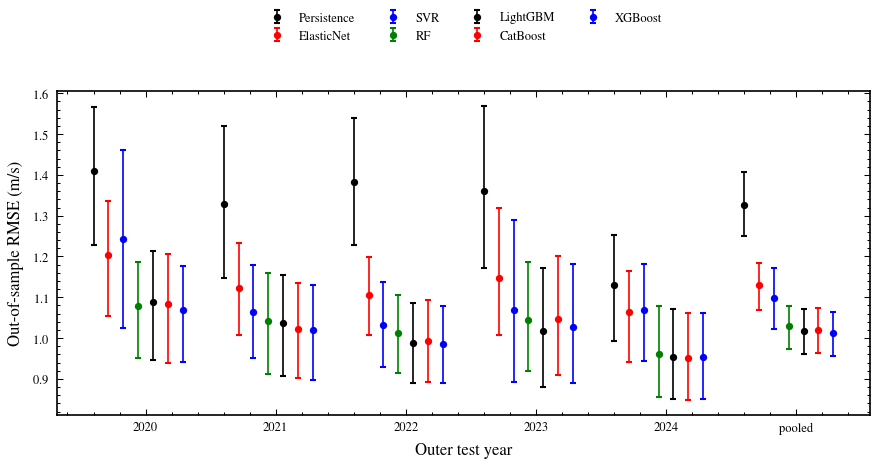

saved figure fig3_series_scatter


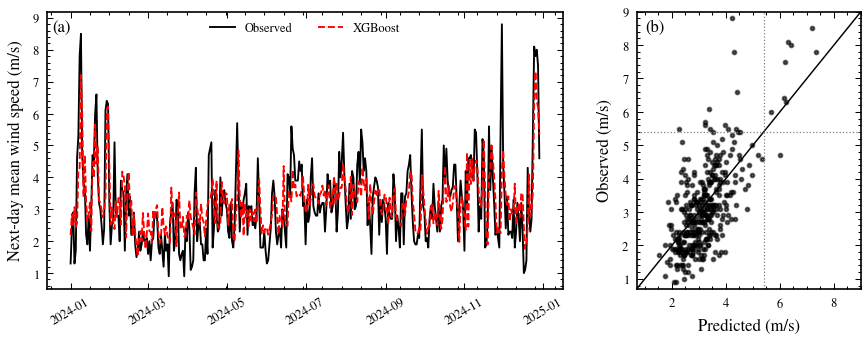

saved figure fig5_month_year_skill


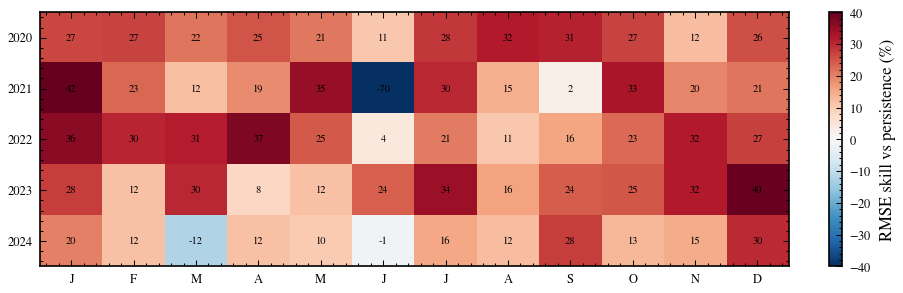

saved figure figS4_residual_diagnostics


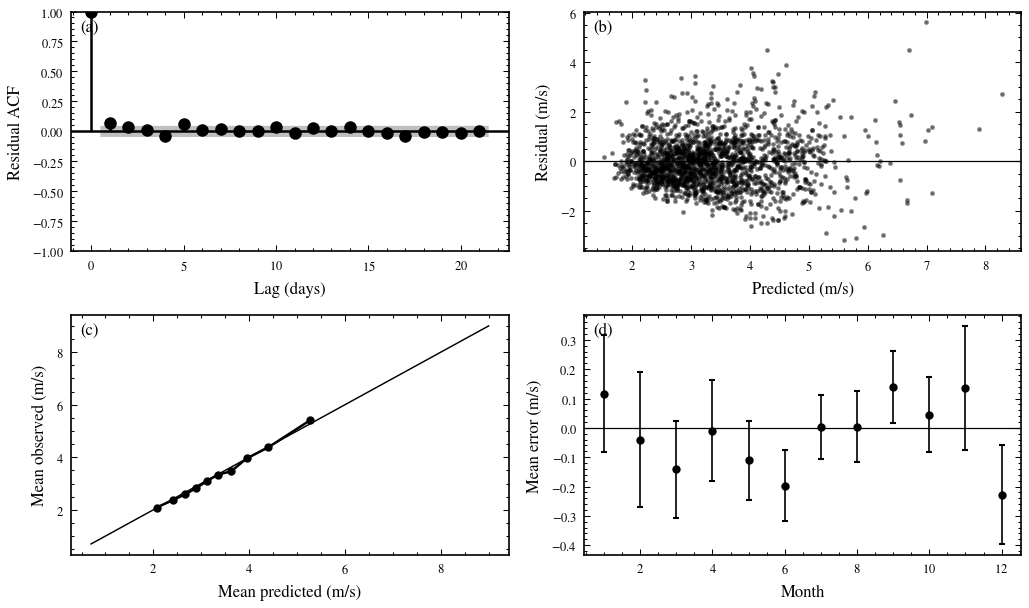

66 values written to /content/drive/MyDrive/windforecast_rev1/revision/results_09.json


In [7]:
# --- Figure 2 (rebuilt), Figure 3, Figure 5 and Figure S4 ---------------------------------------
show = [m for m in ['persistence', 'ElasticNetCV', 'SVR', 'RandomForest', 'LightGBM', 'CatBoost',
                    'XGBoost_selected'] if m in mods]
lab = {'persistence': 'Persistence', 'ElasticNetCV': 'ElasticNet', 'SVR': 'SVR', 'RandomForest': 'RF',
       'LightGBM': 'LightGBM', 'CatBoost': 'CatBoost', 'XGBoost_selected': 'XGBoost'}
years = sorted(R.outer_year.unique()) + ['pooled']
fig, ax = plt.subplots(figsize=(7.0, 2.8))
w = 0.8 / len(show)
for i, m in enumerate(show):
    xs_, ys_, lo_, hi_ = [], [], [], []
    for k, Y in enumerate(years):
        r = U[(U.outer_year == Y) & (U.model == m)]
        if len(r):
            r = r.iloc[0]; xs_.append(k + i * w - 0.4); ys_.append(r.RMSE)
            lo_.append(r.RMSE - r.RMSE_lo); hi_.append(r.RMSE_hi - r.RMSE)
    ax.errorbar(xs_, ys_, yerr=[lo_, hi_], fmt='o', ms=2.5, lw=0.8, capsize=1.5, label=lab[m])
ax.set_xticks(range(len(years))); ax.set_xticklabels([str(y) for y in years])
ax.set_ylabel('Out-of-sample RMSE (m/s)'); ax.set_xlabel('Outer test year')
ax.legend(ncol=4, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.28))
ru.savefig(fig, REV, 'fig2_rolling_origin'); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.4), gridspec_kw={'width_ratios': [2.3, 1]})
axes[0].plot(te.index, te.y_true, lw=0.9, label='Observed')
axes[0].plot(te.index, te['XGBoost (400 trials)'], lw=0.9, ls='--', label='XGBoost')
axes[0].set_ylabel('Next-day mean wind speed (m/s)'); axes[0].legend(frameon=False, ncol=2)
axes[0].tick_params(axis='x', rotation=30)
thr = float(P.loc[P.split != 'test', 'y_true'].quantile(0.90))
axes[1].scatter(te['XGBoost (400 trials)'], te.y_true, s=3, alpha=0.6)
lim = [min(te.y_true.min(), te['XGBoost (400 trials)'].min()) - 0.2, max(te.y_true.max(), te['XGBoost (400 trials)'].max()) + 0.2]
axes[1].plot(lim, lim, 'k-', lw=0.7); axes[1].axhline(thr, color='grey', lw=0.6, ls=':')
axes[1].axvline(thr, color='grey', lw=0.6, ls=':')
axes[1].set_xlabel('Predicted (m/s)'); axes[1].set_ylabel('Observed (m/s)'); axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[0].text(0.01, 0.93, '(a)', transform=axes[0].transAxes); axes[1].text(0.04, 0.93, '(b)', transform=axes[1].transAxes)
ru.savefig(fig, REV, 'fig3_series_scatter'); plt.show()

sk = R.assign(month=R.date.dt.month)
cells = []
for (Y, mth), g in sk.groupby(['outer_year', 'month']):
    cells.append(dict(year=Y, month=mth,
                      skill=100 * (1 - ru.rmse(g.y_true, g.XGBoost_selected) / ru.rmse(g.y_true, g.persistence))))
C = pd.DataFrame(cells).pivot(index='year', columns='month', values='skill')
fig, ax = plt.subplots(figsize=(7.0, 2.2))
im = ax.imshow(C.values, cmap='RdBu_r', vmin=-40, vmax=40, aspect='auto')
ax.set_xticks(range(C.shape[1])); ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'][:C.shape[1]])
ax.set_yticks(range(C.shape[0])); ax.set_yticklabels(C.index)
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        if np.isfinite(C.values[i, j]):
            ax.text(j, i, f'{C.values[i, j]:.0f}', ha='center', va='center', fontsize=5)
fig.colorbar(im, ax=ax, label='RMSE skill vs persistence (%)', fraction=0.03)
ru.savefig(fig, REV, 'fig5_month_year_skill'); plt.show()
npos = int((C.values > 0).sum()); ncell = int(np.isfinite(C.values).sum())
RES.put('FIG5_SENTENCE', f'skill was positive in {npos} of {ncell} month–year cells, highest in {S.loc[S.skill_pct.idxmax(), "season"]} '
        f'({S.skill_pct.max():.0f}%) and lowest in {S.loc[S.skill_pct.idxmin(), "season"]} ({S.skill_pct.min():.0f}%)')

fig, axs = plt.subplots(2, 2, figsize=(7.0, 4.2))
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(e, lags=21, ax=axs[0, 0], title=''); axs[0, 0].set_xlabel('Lag (days)'); axs[0, 0].set_ylabel('Residual ACF')
axs[0, 1].scatter(R.XGBoost_selected, e, s=2, alpha=0.4); axs[0, 1].axhline(0, color='k', lw=0.6)
axs[0, 1].set_xlabel('Predicted (m/s)'); axs[0, 1].set_ylabel('Residual (m/s)')
q = pd.qcut(R.XGBoost_selected, 10, duplicates='drop')
rel = R.assign(q=q).groupby('q', observed=True).agg(p=('XGBoost_selected', 'mean'), o=('y_true', 'mean'))
axs[1, 0].plot(rel.p, rel.o, 'o-', ms=3); axs[1, 0].plot(lim, lim, 'k-', lw=0.7)
axs[1, 0].set_xlabel('Mean predicted (m/s)'); axs[1, 0].set_ylabel('Mean observed (m/s)')
axs[1, 1].errorbar(mb.index, mb['mean'], yerr=1.96 * mb['se'], fmt='o', ms=3, lw=0.8, capsize=1.5)
axs[1, 1].axhline(0, color='k', lw=0.6); axs[1, 1].set_xlabel('Month'); axs[1, 1].set_ylabel('Mean error (m/s)')
for a, t in zip(axs.ravel(), ['(a)', '(b)', '(c)', '(d)']):
    a.text(0.02, 0.92, t, transform=a.transAxes)
fig.tight_layout(); ru.savefig(fig, REV, 'figS4_residual_diagnostics'); plt.show()
RES.save()
